# Transfer Portal Exploratory Data Analysis

This notebook explores the NCAA basketball transfer portal dataset (2022–2025) to understand transfer patterns, success rates, and key factors before modeling.

**Dataset**: 1,149 transfers across 4 seasons, 190 origin teams, 189 destination teams.

**Target variable**: Transfer "succeeds" if post-transfer ORtg ≥ pre-transfer ORtg.

In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

transfers = pl.read_parquet('data/raw/transfers.parquet')
team_stats = pl.read_parquet('data/raw/team_stats.parquet')

print(f'Transfers: {transfers.shape}')
print(f'Team stats: {team_stats.shape}')
print(f'\nTransfer columns ({len(transfers.columns)}):')
print(transfers.columns)

Transfers: (1149, 53)
Team stats: (955, 13)

Transfer columns (53):
['player', 'pid', 'origin_team', 'origin_conf', 'dest_team', 'dest_conf', 'transfer_season', 'recruiting_stars', 'class_year', 'height_in', 'pre_g', 'pre_mpg', 'pre_ortg', 'pre_usg', 'pre_efg', 'pre_ts_pct', 'pre_ast_pct', 'pre_to_pct', 'pre_orb_pct', 'pre_drb_pct', 'pre_blk_pct', 'pre_stl_pct', 'pre_ftr', 'pre_porpag', 'pre_bpm', 'pre_obpm', 'pre_dbpm', 'post_g', 'post_mpg', 'post_ortg', 'post_usg', 'post_efg', 'post_ts_pct', 'post_ast_pct', 'post_to_pct', 'post_orb_pct', 'post_drb_pct', 'post_blk_pct', 'post_stl_pct', 'post_ftr', 'post_porpag', 'post_bpm', 'post_obpm', 'post_dbpm', 'origin_adj_o', 'origin_adj_d', 'origin_adj_t', 'origin_barthag', 'dest_adj_o', 'dest_adj_d', 'dest_adj_t', 'dest_barthag', 'success']


In [ ]:
# Target variable distribution
print('=== Target: Transfer Success ===')
print(f'Success rate: {transfers["success"].mean():.3f}')
print(f'Successes: {transfers.filter(pl.col("success") == 1).height}')
print(f'Declines:  {transfers.filter(pl.col("success") == 0).height}')

print('\n=== By Season ===')
print(transfers.group_by('transfer_season').agg([
    pl.count().alias('n'),
    pl.col('success').mean().alias('success_rate'),
]).sort('transfer_season'))

=== Target: Transfer Success ===
Success rate: 0.521
Successes: 599
Declines:  550

=== By Season ===
shape: (4, 3)
┌─────────────────┬─────┬──────────────┐
│ transfer_season ┆ n   ┆ success_rate │
│ ---             ┆ --- ┆ ---          │
│ i64             ┆ u32 ┆ f64          │
╞═════════════════╪═════╪══════════════╡
│ 2022            ┆ 280 ┆ 0.546429     │
│ 2023            ┆ 267 ┆ 0.520599     │
│ 2024            ┆ 303 ┆ 0.531353     │
│ 2025            ┆ 299 ┆ 0.488294     │
└─────────────────┴─────┴──────────────┘


## 1. Transfer Volume and Success Rate by Season

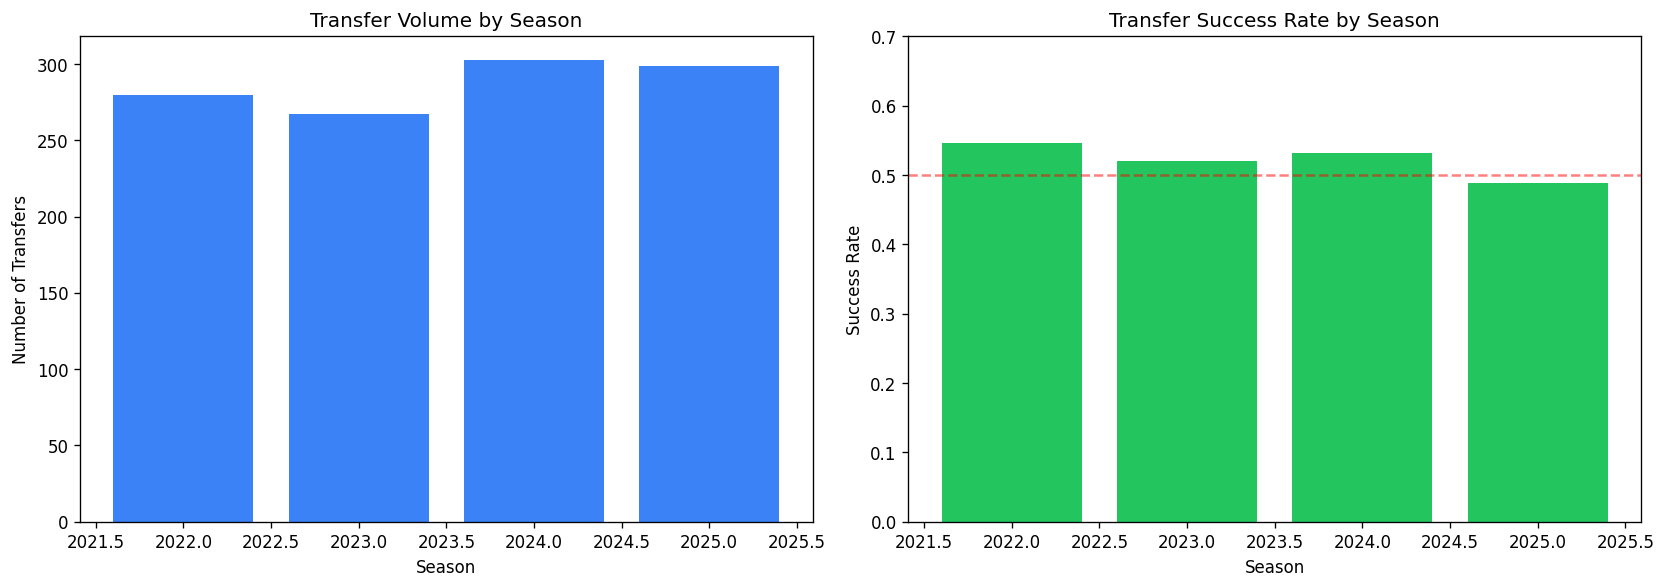

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_data = transfers.group_by('transfer_season').agg([
    pl.count().alias('n'),
    pl.col('success').mean().alias('success_rate'),
]).sort('transfer_season').to_pandas()

axes[0].bar(season_data['transfer_season'], season_data['n'], color='#3b82f6')
axes[0].set_xlabel('Season'); axes[0].set_ylabel('Number of Transfers')
axes[0].set_title('Transfer Volume by Season')

axes[1].bar(season_data['transfer_season'], season_data['success_rate'], color='#22c55e')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Season'); axes[1].set_ylabel('Success Rate')
axes[1].set_title('Transfer Success Rate by Season')
axes[1].set_ylim(0, 0.7)

plt.tight_layout()
plt.show()

## 2. Conference Jump Direction

     jump_type    n  success_rate  avg_ortg_delta
0    Mid→Power  435         0.589            1.40
1  Power→Power  170         0.541            0.19
2      Mid→Mid  339         0.519            0.12
3    Power→Mid  205         0.366           -1.93


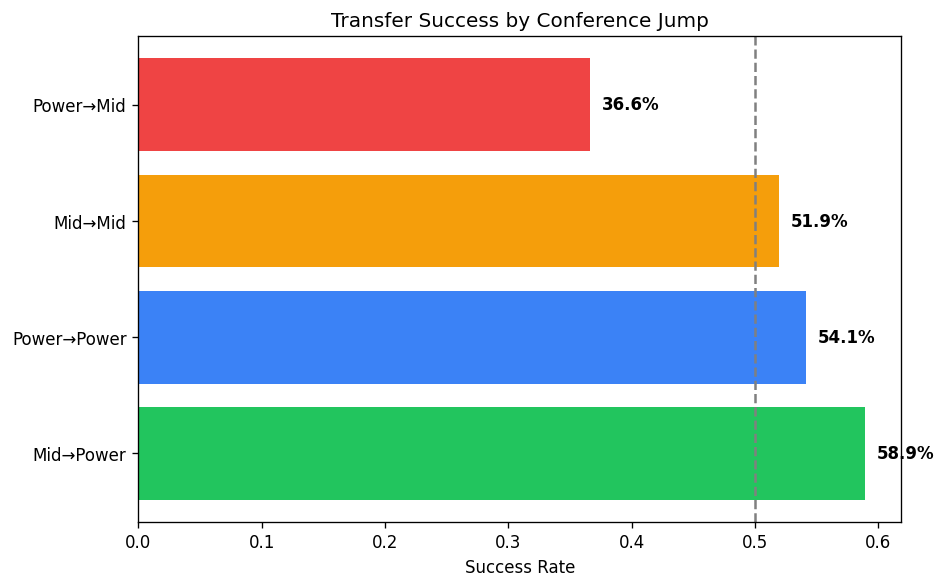

In [ ]:
# Conference jump analysis using DuckDB
con = duckdb.connect(':memory:')
con.execute("CREATE VIEW t AS SELECT * FROM read_parquet('data/raw/transfers.parquet')")

jump_df = con.execute("""
WITH conf_jumps AS (
    SELECT *,
        CASE
            WHEN origin_conf IN ('ACC','B10','SEC','B12','BE')
                 AND dest_conf IN ('ACC','B10','SEC','B12','BE') THEN 'Power→Power'
            WHEN origin_conf IN ('ACC','B10','SEC','B12','BE')
                 AND dest_conf NOT IN ('ACC','B10','SEC','B12','BE') THEN 'Power→Mid'
            WHEN origin_conf NOT IN ('ACC','B10','SEC','B12','BE')
                 AND dest_conf IN ('ACC','B10','SEC','B12','BE') THEN 'Mid→Power'
            ELSE 'Mid→Mid'
        END AS jump_type
    FROM t
)
SELECT jump_type, COUNT(*) AS n, ROUND(AVG(success),3) AS success_rate,
       ROUND(AVG(post_ortg - pre_ortg),2) AS avg_ortg_delta
FROM conf_jumps GROUP BY jump_type ORDER BY success_rate DESC
""").fetchdf()

print(jump_df)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#22c55e', '#3b82f6', '#f59e0b', '#ef4444']
ax.barh(jump_df['jump_type'], jump_df['success_rate'], color=colors)
ax.axvline(x=0.5, color='gray', linestyle='--')
ax.set_xlabel('Success Rate'); ax.set_title('Transfer Success by Conference Jump')
for i, v in enumerate(jump_df['success_rate']):
    ax.text(v + 0.01, i, f'{v:.1%}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Pre vs Post Transfer Offensive Rating Distribution

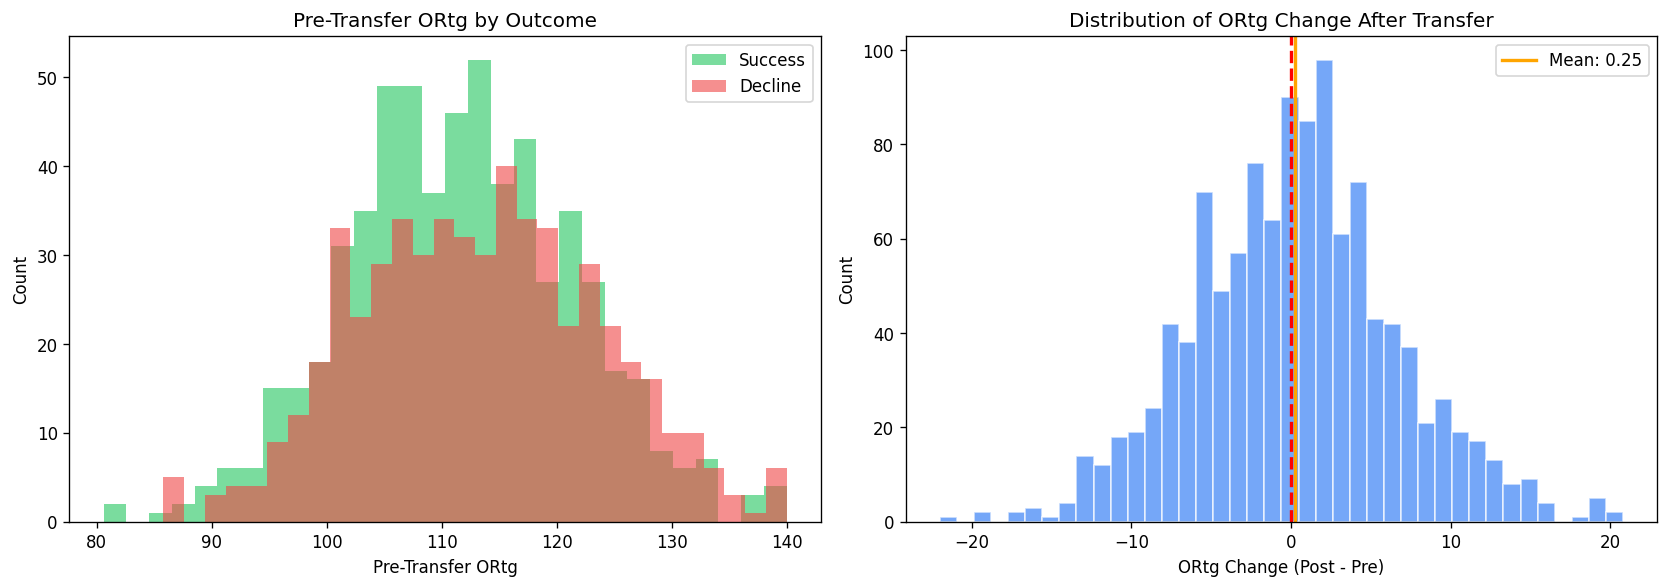

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tf = transfers.to_pandas()

# ORtg distribution split by outcome
axes[0].hist(tf[tf['success']==1]['pre_ortg'], bins=30, alpha=0.6, label='Success', color='#22c55e')
axes[0].hist(tf[tf['success']==0]['pre_ortg'], bins=30, alpha=0.6, label='Decline', color='#ef4444')
axes[0].set_xlabel('Pre-Transfer ORtg'); axes[0].set_ylabel('Count')
axes[0].set_title('Pre-Transfer ORtg by Outcome'); axes[0].legend()

# ORtg delta distribution
delta = tf['post_ortg'] - tf['pre_ortg']
axes[1].hist(delta, bins=40, color='#3b82f6', alpha=0.7, edgecolor='white')
axes[1].axvline(x=0, color='red', linewidth=2, linestyle='--')
axes[1].axvline(x=delta.mean(), color='orange', linewidth=2, label=f'Mean: {delta.mean():.2f}')
axes[1].set_xlabel('ORtg Change (Post - Pre)'); axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of ORtg Change After Transfer'); axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Feature Correlation with Success

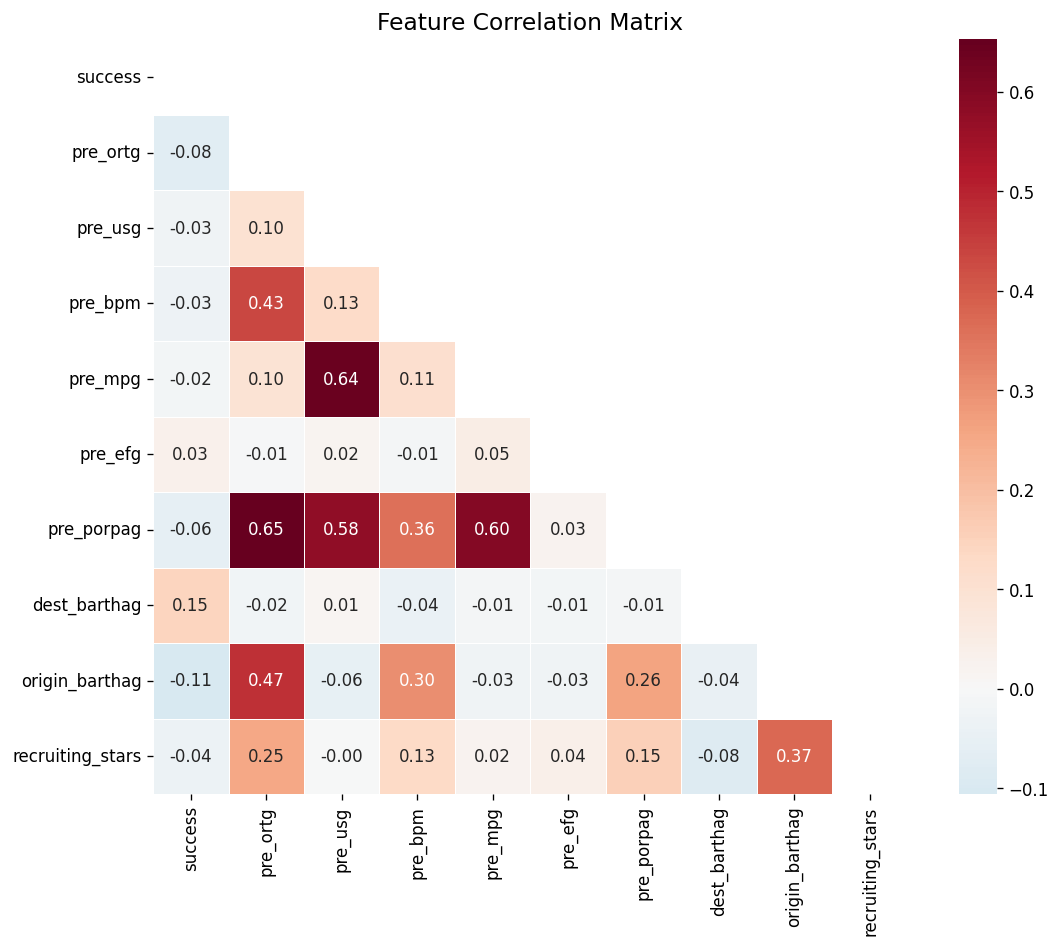


Top correlations with success:
dest_barthag        0.148535
pre_efg             0.033006
pre_mpg            -0.015216
pre_usg            -0.027683
pre_bpm            -0.030842
recruiting_stars   -0.035596
pre_porpag         -0.055852
pre_ortg           -0.075189
origin_barthag     -0.105761


In [ ]:
# Key feature correlations with success
corr_cols = ['success', 'pre_ortg', 'pre_usg', 'pre_bpm', 'pre_mpg', 'pre_efg',
             'pre_porpag', 'dest_barthag', 'origin_barthag', 'recruiting_stars']
corr = tf[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

print('\nTop correlations with success:')
print(corr['success'].drop('success').sort_values(ascending=False).to_string())

## 5. Transfer Outcomes by Class Year and Recruiting Stars

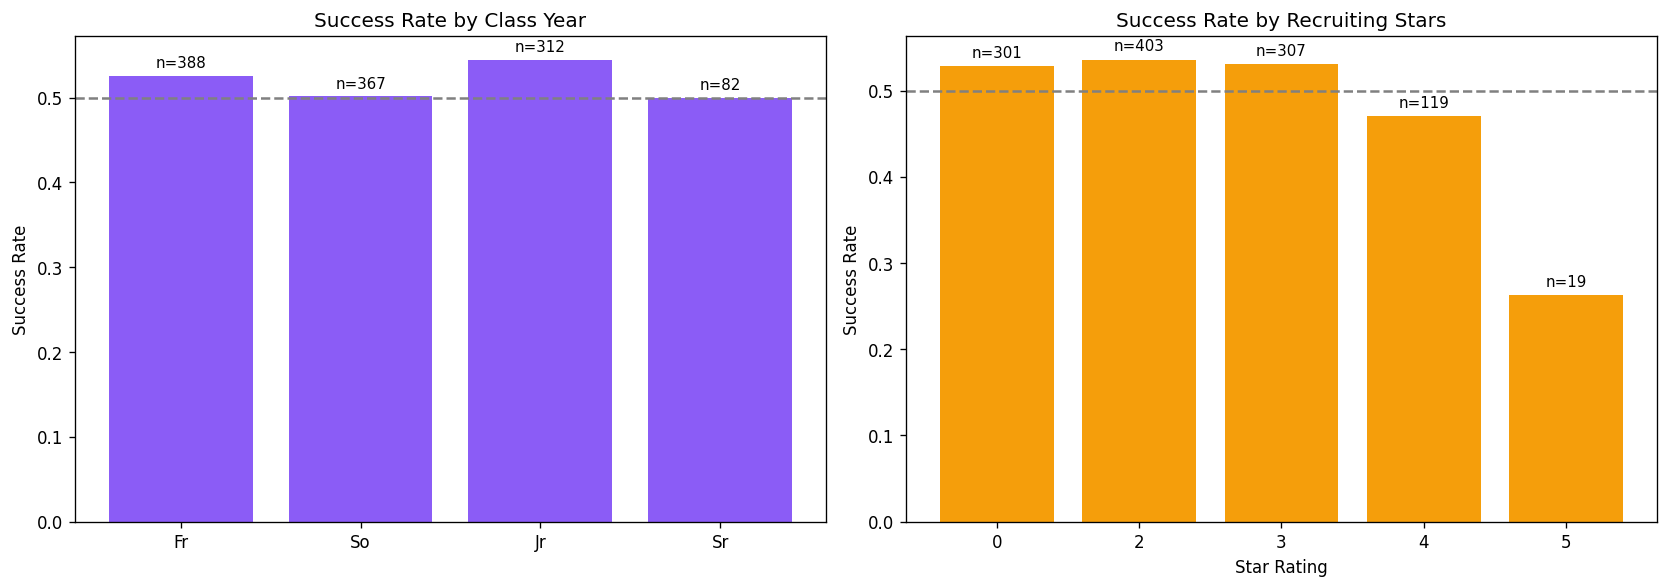

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By class year
cy = transfers.group_by('class_year').agg([
    pl.count().alias('n'), pl.col('success').mean().alias('rate')
]).sort('class_year').to_pandas()
order = ['Fr','So','Jr','Sr']
cy = cy.set_index('class_year').reindex(order).reset_index()
axes[0].bar(cy['class_year'], cy['rate'], color='#8b5cf6')
axes[0].axhline(y=0.5, color='gray', linestyle='--')
axes[0].set_title('Success Rate by Class Year'); axes[0].set_ylabel('Success Rate')
for i, (_, row) in enumerate(cy.iterrows()):
    axes[0].text(i, row['rate']+0.01, f'n={int(row["n"])}', ha='center', fontsize=9)

# By recruiting stars
rs = transfers.group_by('recruiting_stars').agg([
    pl.count().alias('n'), pl.col('success').mean().alias('rate')
]).sort('recruiting_stars').to_pandas()
axes[1].bar(rs['recruiting_stars'].astype(str), rs['rate'], color='#f59e0b')
axes[1].axhline(y=0.5, color='gray', linestyle='--')
axes[1].set_title('Success Rate by Recruiting Stars'); axes[1].set_ylabel('Success Rate')
axes[1].set_xlabel('Star Rating')
for i, (_, row) in enumerate(rs.iterrows()):
    axes[1].text(i, row['rate']+0.01, f'n={int(row["n"])}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Destination Team Quality vs Transfer Success

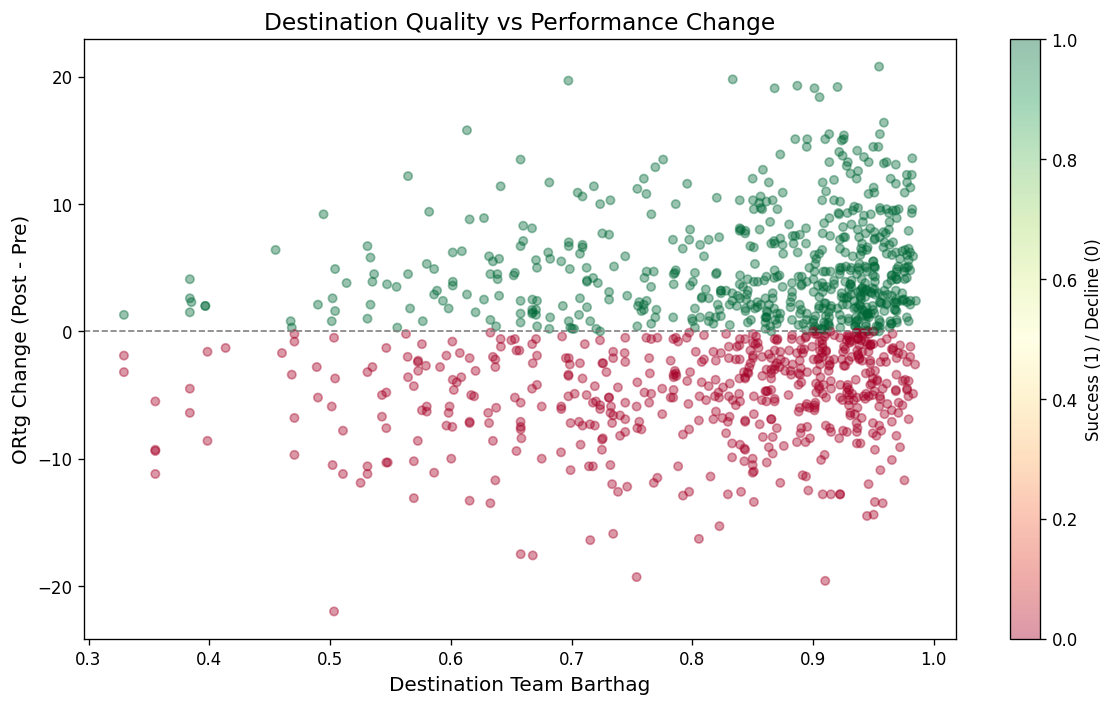

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(tf['dest_barthag'], tf['post_ortg'] - tf['pre_ortg'],
                     c=tf['success'], cmap='RdYlGn', alpha=0.4, s=25)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Destination Team Barthag', fontsize=12)
ax.set_ylabel('ORtg Change (Post - Pre)', fontsize=12)
ax.set_title('Destination Quality vs Performance Change', fontsize=14)
plt.colorbar(scatter, label='Success (1) / Decline (0)')
plt.tight_layout()
plt.show()

## Key EDA Takeaways

1. **Overall success rate is ~52%** — nearly a coin flip, confirming this is a hard prediction problem.
2. **Mid → Power transfers succeed most often (58.9%)** — players stepping up from mid-majors often thrive.
3. **Power → Mid transfers struggle (36.6%)** — stepping down in competition doesn't guarantee improvement.
4. **Juniors have the highest success rate** — experience + remaining eligibility is the sweet spot.
5. **Destination team quality (Barthag) positively correlates with success** — better teams lift player performance.
6. **Pre-transfer BPM and PORPAG have weak but positive correlation with success** — already-good players tend to stay good.
7. **The ORtg change distribution is roughly symmetric around zero** — no systematic direction of improvement, making prediction valuable.